# Sección 9. Análisis de contenido y sentimiento

Se etiqueta el sentimiento de los 406 comentarios con un modelo entrenado en español y se
compara el resultado por video, canal y comunidad de autores (Sec. 7). Los comentarios son
reacciones a noticias y política de Guatemala, así que el interés está en distinguir tono
crítico de tono de apoyo, no en medir emociones finas.

El modelo se ejecuta una sola vez y su salida se cachea en
`outputs/tablas/sentimiento_comentarios.csv`; el resto del análisis lee esa tabla.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import eda
import sentimiento as sent

FIGURAS = REPO / "outputs" / "figuras"
TABLAS = REPO / "outputs" / "tablas"
FIGURAS.mkdir(parents=True, exist_ok=True)
TABLAS.mkdir(parents=True, exist_ok=True)

videos, comments = eda.cargar_procesados()
por_video_tab = pd.read_csv(TABLAS / "eda_por_video.csv")
comunidades = pd.read_csv(TABLAS / "comunidades.csv")[["nodo", "comunidad"]]
caracterizacion = pd.read_csv(TABLAS / "comunidades_caracterizacion.csv")
print(f"{len(comments)} comentarios, {comments['video_id'].nunique()} videos, "
      f"{comments['channel_id'].nunique()} canales")

406 comentarios, 19 videos, 8 canales


## 9.1. Modelo de sentimiento y justificación

Se usa **`pysentimiento`** con el modelo `robertuito-sentiment-analysis`: un RoBERTa
preentrenado con tuits en español y ajustado con el corpus **TASS**. Devuelve tres clases
(positivo / neutral / negativo) y sus probabilidades. Se resume cada comentario con un
puntaje continuo `score = P(pos) − P(neg)` en el rango [−1, 1].

| Opción | Idioma | Problema para estos datos |
|---|---|---|
| VADER | inglés | Léxico y reglas en inglés; ignora vocabulario y negación en español. |
| Léxico es (p. ej. iSOL) | español | Bolsa de palabras: no modela negación ni contexto. |
| **pysentimiento (RoBERTa-es)** | **español** | **Modelo contextual entrenado en redes en español.** |

Se aplica sobre `texto_original`: el modelo hace su propia normalización (usuarios, hashtags,
risas, emojis) y el texto sin recortar conserva la negación y la puntuación que aprovecha.
`texto_limpio` —sin stopwords ni signos— degradaría la señal.

**Limitación.** El modelo mide la *polaridad del texto del comentario*, no la opinión sobre
una persona: "que caiga preso el corrupto" es negativo en tono aunque exprese aprobación de
una acción. La ironía tampoco se detecta de forma confiable. El puntaje describe el tono
observado, no la postura del autor.

In [2]:
# Ejecuta (o carga desde caché) el modelo de sentimiento en español.
df = sent.analizar_comentarios(comments, texto="texto_original")

dist = df["etiqueta"].value_counts().reindex(["positivo", "neutral", "negativo"]).fillna(0).astype(int)
pct = (100 * dist / dist.sum()).round(1)
resumen_global = pd.DataFrame({"comentarios": dist, "porcentaje": pct})
print(f"Score medio global: {df['score'].mean():.3f}  (negativo < 0 < positivo)")
display(resumen_global)

Score medio global: -0.379  (negativo < 0 < positivo)


,comentarios,porcentaje
etiqueta,,
positivo,78,19.2
neutral,79,19.5
negativo,249,61.3


In [3]:
# Ejemplos: comentarios más negativos y más positivos según el modelo.
muestra = df.merge(comments[["comment_id", "texto_original"]].astype({"comment_id": "string"}),
                   on="comment_id", how="left")
cols = ["etiqueta", "score", "texto_original"]
print("— Más negativos —")
for _, r in muestra.nsmallest(3, "score")[cols].iterrows():
    print(f"  [{r.score:+.2f}] {r.texto_original[:95]}")
print("\n— Más positivos —")
for _, r in muestra.nlargest(3, "score")[cols].iterrows():
    print(f"  [{r.score:+.2f}] {r.texto_original[:95]}")

— Más negativos —
  [-0.98] Que indignante saber como se artan estos coches y finalmente el pueblo esta ciendo dañado
  [-0.98] Ni el mismo lo cree, estos son sinverguenzas y se pasan de pija, cómo se sentirá la familia ten
  [-0.98] Y solo con esta información nos damos con la realidad del CACIF y sus intereses, estamos jodido

— Más positivos —
  [+0.98] Es un proyecto extraordinario , vamos adelante mi guate hermosa!
  [+0.97] Que bueno que Guatemala sea una cuidad bonita y ojalá todos los proyectos sean realidad. Se los
  [+0.97] Se ve moderna Y bella la ciudad de Guatemala .......Saludos desde Ecuador


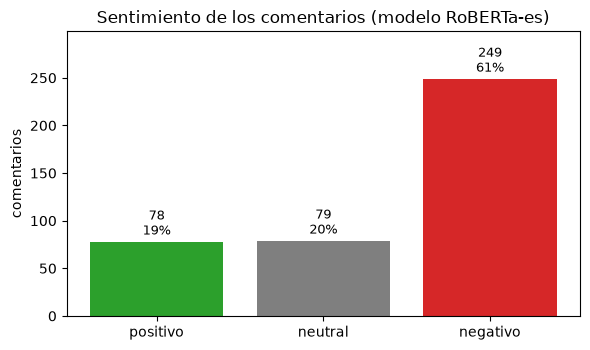

In [4]:
# Figura 09.1 — distribución global de sentimiento.
fig, ax = plt.subplots(figsize=(6, 3.6))
colores = {"positivo": "#2ca02c", "neutral": "#7f7f7f", "negativo": "#d62728"}
ax.bar(dist.index, dist.values, color=[colores[k] for k in dist.index])
for i, (k, v) in enumerate(dist.items()):
    ax.text(i, v + 3, f"{v}\n{pct[k]:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("comentarios")
ax.set_title("Sentimiento de los comentarios (modelo RoBERTa-es)")
ax.set_ylim(0, dist.max() * 1.2)
fig.tight_layout()
fig.savefig(FIGURAS / "09_sentimiento_global.png", dpi=140)
plt.show()

## 9.2. Comparación por video, canal y comunidad

Se agrega el sentimiento por los tres niveles con sentido en estos datos. Solo se interpretan
los grupos con al menos `sent.MIN_MUESTRA` = 10 comentarios; el resto se reporta pero se
marca como muestra insuficiente (Sec. 9.2: *cuando el tamaño de muestra lo permita*).

In [5]:
# Por video (los que concentran comentarios).
vid = sent.por_video(df, por_video_tab)
vid.to_csv(TABLAS / "sentimiento_por_video.csv", index=False)
display(vid[vid["muestra_suficiente"]][
    ["video_id", "title", "channel_name", "n_comentarios", "score_medio", "pct_negativo"]
].head(10))

,video_id,title,channel_name,n_comentarios,score_medio,pct_negativo
0,n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,-0.6709,80.7
1,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,-0.3422,58.0
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,45,-0.1086,40.0
3,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,0.6094,8.0
4,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,25,-0.4223,68.0
5,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,25,-0.4731,64.0
6,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,-0.2357,56.2
7,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,14,-0.1765,28.6
8,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,12,0.0020,33.3


In [6]:
# Por canal propietario del video comentado.
canal = sent.por_canal(df)
canal.to_csv(TABLAS / "sentimiento_por_canal.csv", index=False)
display(canal[["canal", "n_comentarios", "score_medio", "positivo", "neutral", "negativo",
               "pct_negativo", "muestra_suficiente"]])

,canal,n_comentarios,score_medio,positivo,neutral,negativo,pct_negativo,muestra_suficiente
0,Quorum,256,-0.5022,36,41,179,69.9,True
1,Gobierno de la República de Guatemala,70,-0.2206,17,18,35,50.0,True
2,Noticias Telemundo,25,-0.4731,2,7,16,64.0,True
3,Municipalidad de Guatemala,25,0.6094,20,3,2,8.0,True
4,Noti7,14,-0.1765,3,7,4,28.6,True
5,PrensaLibreOficial,7,-0.7590,0,1,6,85.7,False
6,TN23 Guatemala,7,-0.6218,0,1,6,85.7,False
7,Noticiero Guatevisión 13 Hrs.,2,-0.5193,0,1,1,50.0,False


In [7]:
# Por comunidad de autores (Sec. 7). Se une con la caracterización temática.
com = sent.por_comunidad(df, comunidades)
com = com.merge(
    caracterizacion[["comunidad", "autores", "videos_principales", "canales_principales"]],
    on="comunidad", how="left")
com.to_csv(TABLAS / "sentimiento_por_comunidad.csv", index=False)
display(com[["comunidad", "n_comentarios", "score_medio", "pct_negativo",
             "muestra_suficiente", "canales_principales"]])

,comunidad,n_comentarios,score_medio,pct_negativo,muestra_suficiente,canales_principales
0,1,161,-0.6689,80.7,True,Quorum (159); Gobierno de la República de Guat...
1,2,83,-0.2072,45.8,True,Gobierno de la República de Guatemala (69); No...
2,3,60,-0.3757,61.7,True,Quorum (53); TN23 Guatemala (7)
3,4,33,-0.2368,51.5,True,NaN
4,5,25,0.6094,8.0,True,NaN
5,6,25,-0.4731,64.0,True,NaN
6,7,6,-0.7600,83.3,False,NaN
7,8,4,0.4666,25.0,False,NaN
8,9,3,0.1573,33.3,False,NaN
9,10,2,-0.5193,50.0,False,NaN


El tono es **mayoritariamente negativo**, coherente con un corpus dominado por noticias sobre
corrupción y política. Pero la diferencia entre grupos **sí cambia de dirección** en un caso
claro: el canal **Municipalidad de Guatemala** y su comunidad (video *Plan 2032 Ciudad de
Guatemala*, contenido promocional/aspiracional) son **netamente positivos** (score ≈ +0.61,
8 % negativo), frente a la fuerte negatividad de los videos de escándalo político como *Qué
rico come tu diputado* del canal Quorum (score ≈ −0.67, 81 % negativo). El sentimiento no lo
marca el canal en abstracto sino **el tipo de contenido**: denuncia frente a promoción. Los
videos y comunidades pequeñas se reportan pero no se interpretan por falta de muestra.

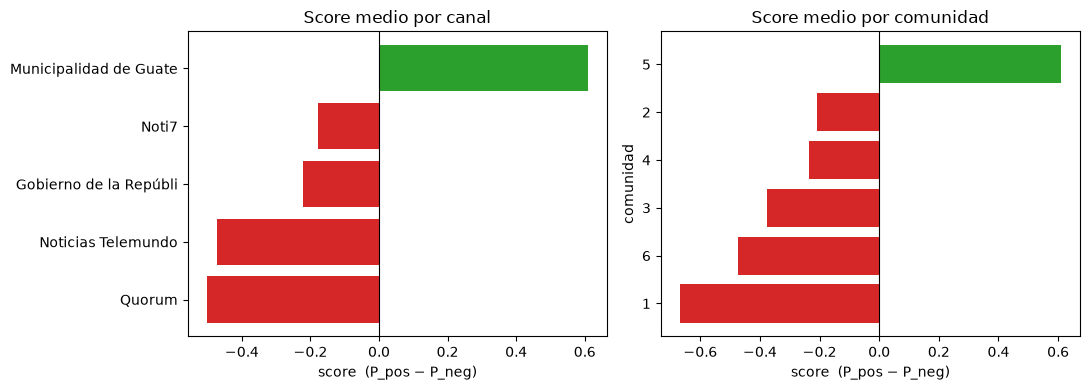

In [8]:
# Figura 09.2 — score medio por canal y por comunidad (solo muestra suficiente).
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

c = canal[canal["muestra_suficiente"]].sort_values("score_medio")
axes[0].barh(c["canal"].str.slice(0, 22), c["score_medio"],
             color=np.where(c["score_medio"] < 0, "#d62728", "#2ca02c"))
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Score medio por canal")
axes[0].set_xlabel("score  (P_pos − P_neg)")

m = com[com["muestra_suficiente"]].sort_values("score_medio")
axes[1].barh(m["comunidad"].astype(str), m["score_medio"],
             color=np.where(m["score_medio"] < 0, "#d62728", "#2ca02c"))
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Score medio por comunidad")
axes[1].set_xlabel("score  (P_pos − P_neg)")
axes[1].set_ylabel("comunidad")

fig.tight_layout()
fig.savefig(FIGURAS / "09_sentimiento_por_grupo.png", dpi=140)
plt.show()

## 9.3. Hallazgos

- **El tono dominante es negativo.** El 61 % de los comentarios es negativo (score medio
  global −0.38), consistente con temas de corrupción y política.
- **El sentimiento depende del tipo de contenido, no solo del canal.** Un grupo con muestra
  suficiente es netamente positivo —Municipalidad de Guatemala / *Plan 2032* (+0.61, 8 % neg.),
  contenido promocional— frente a la fuerte negatividad de los videos de denuncia (*Qué rico
  come tu diputado*, −0.67, 81 % neg.). El sentimiento coincide con la comunidad cuando esta
  se organiza alrededor de un video de tono homogéneo (Sec. 7).
- **La comparación fina está limitada por la muestra.** Con 406 comentarios repartidos en 19
  videos, la mayoría de videos y comunidades quedan por debajo del umbral de 10 comentarios;
  sus promedios se muestran pero no se interpretan.
- **El modelo mide tono del texto, no postura.** Un comentario que celebra que 'caiga preso un
  corrupto' es negativo en polaridad. El puntaje describe el lenguaje observado, no la opinión
  del autor sobre los hechos.

In [9]:
# --- Auto-verificación ------------------------------------------------------
assert len(df) == len(comments) == 406, len(df)
assert set(df["etiqueta"].unique()) <= {"positivo", "neutral", "negativo"}
assert df["score"].between(-1, 1).all()
assert np.allclose(df[["prob_pos", "prob_neu", "prob_neg"]].sum(axis=1), 1.0, atol=1e-3)

assert vid["n_comentarios"].sum() == 406
assert canal["n_comentarios"].sum() == 406

for f in ["sentimiento_comentarios.csv", "sentimiento_por_video.csv",
          "sentimiento_por_canal.csv", "sentimiento_por_comunidad.csv"]:
    assert (TABLAS / f).exists(), f
for f in ["09_sentimiento_global.png", "09_sentimiento_por_grupo.png"]:
    assert (FIGURAS / f).exists(), f

print("Etapa 9: self-check OK")
print(f"  score medio global = {df['score'].mean():.3f} | "
      f"neg={ (df['etiqueta']=='negativo').mean():.0%}, "
      f"neu={ (df['etiqueta']=='neutral').mean():.0%}, "
      f"pos={ (df['etiqueta']=='positivo').mean():.0%}")

Etapa 9: self-check OK
  score medio global = -0.379 | neg=61%, neu=19%, pos=19%
